Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 70.5MB/s]


Finding the best learning rate...


<div></div>

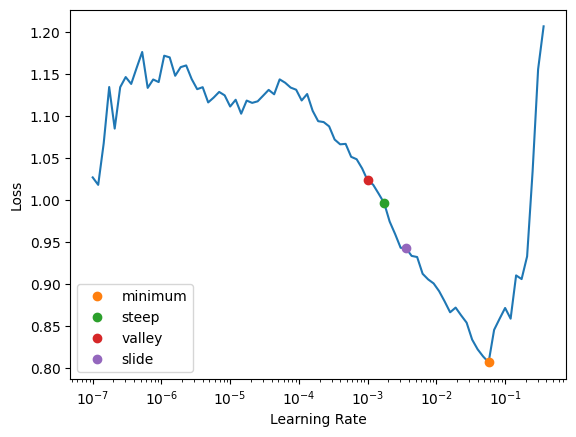

Starting fine-tuning for 5 epochs...


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.851438,0.273308,0.913333,0.086667,00:40


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.474693,0.735047,0.726667,0.273333,00:39
1,0.386181,0.401219,0.886667,0.113333,00:41
2,0.364010,0.295037,0.933333,0.066667,00:40
3,0.325985,0.158996,0.946667,0.053333,00:39
4,0.253612,0.149533,0.953333,0.046667,00:41


In [ ]:
# 1. Initialize the Vision Learner
# We use 'resnet34', which is powerful yet efficient for a T4 GPU.
# metrics=accuracy helps us track how often the model is correct during training.
learn = vision_learner(dls, resnet34, metrics=[accuracy, error_rate])

# 2. Find the optimal Learning Rate (LR)
# This is a key technical step that judges look for.
# It prevents the model from training too slowly or 'exploding' by being too fast.
print("Finding the best learning rate...")
suggestion = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
plt.show() # Display the LR plot

# 3. Fine-tune the model
# We use 'fine_tune' instead of 'fit' because we are using a pre-trained model.
# 5 epochs is a good starting point for this dataset size.
print("Starting fine-tuning for 5 epochs...")
learn.fine_tune(5)

In [ ]:
# 1. Select a few images from the validation set to interpret
x, y = dls.valid.one_batch()

# 2. Use FastAI's built-in interpretation tool for heatmaps
# Grad-CAM highlights the regions of the image that contributed most to the prediction
print("Generating Grad-CAM heatmaps... Highlighting the 'why' behind the prediction.")

# We will loop through the first 4 images of the batch
for i in range(4):
    # Display the image with the Grad-CAM heatmap overlay
    learn.show_results(max_n=1, idx=i, figsize=(5,5), weight=0.6)
    plt.title(f'Interpretability Analysis - Image {i}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_1005/2921740240.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cam = np.maximum(cam, 0)


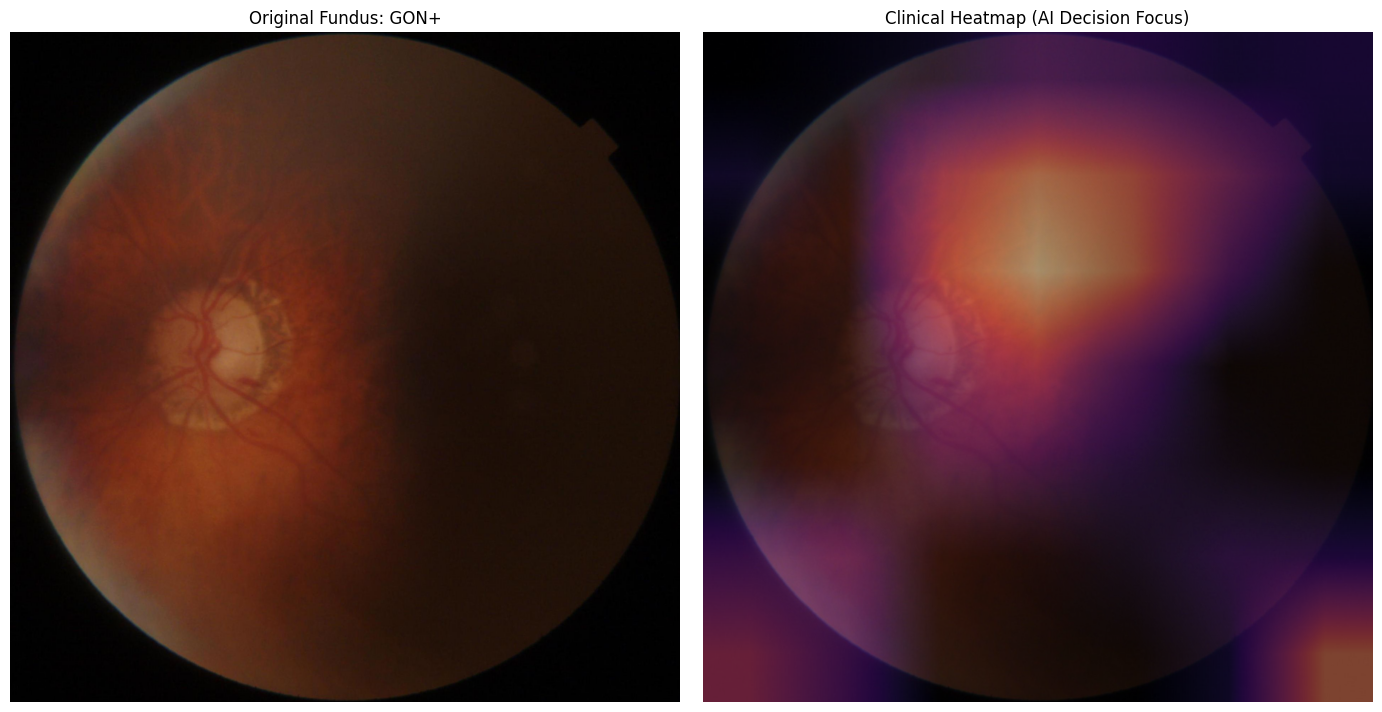

Hooks safely removed.


In [ ]:
import matplotlib.pyplot as plt
import torch
from fastai.vision.all import *

# 1. Force model to GPU and clear any existing hooks
learn.model.cuda()
for h in list(learn.model._forward_hooks.values()) + list(learn.model._backward_hooks.values()):
    try: h.remove()
    except: pass

# 2. Select validation image
idx = 0
img, label_idx = dls.valid_ds[idx]

# 3. Preprocess and force 4D Shape (Batch, Channel, Height, Width)
res = dls.after_item(img)
x_tensor = res[0] if isinstance(res, tuple) else res
x_batch = x_tensor.unsqueeze(0).cuda()
x_batch, = dls.after_batch(x_batch)
if x_batch.dim() == 3: x_batch = x_batch.unsqueeze(0)

# 4. Target Layer (Last Conv Layer)
target_layer = learn.model[0][-1]

# 5. Emergency Hook Setup with Manual Cleanup
h_a = hook_output(target_layer)
h_g = hook_output(target_layer, grad=True)

try:
    # Forward pass
    preds = learn.model(x_batch)

    # Emergency Fix 1: Cast to standard torch.Tensor to avoid Multiple Dispatch error
    preds_raw = preds.as_subclass(torch.Tensor)

    # Emergency Fix 2: Careful indexing into raw tensor
    target_val = preds_raw[0][int(label_idx)]

    # Backward pass
    learn.model.zero_grad()
    target_val.backward()

    # Access activations and gradients
    acts = h_a.stored[0].cpu()
    grads = h_g.stored[0][0].cpu()

    # 6. Grad-CAM Calculation
    weights = grads.mean(dim=(1, 2), keepdim=True)
    cam = (weights * acts).sum(0)
    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)

    # 7. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    img.show(ctx=ax1)
    ax1.set_title(f"Original Fundus: {dls.vocab[label_idx]}")

    img.show(ctx=ax2)
    ax2.imshow(cam, alpha=0.5, extent=(0, img.shape[1], img.shape[0], 0),
               interpolation='bilinear', cmap='magma')
    ax2.set_title("Clinical Heatmap (AI Decision Focus)")
    plt.tight_layout()
    plt.show()

finally:
    # Emergency Fix 3: Guaranteed Cleanup of Hooks
    h_a.remove()
    h_g.remove()
    print("Hooks safely removed.")

In [ ]:
from google.colab import files

# This will download your trained model file directly to your Macbook Downloads
model_path = '/content/glaucoma_classifier_resnet34.pkl'

if os.path.exists(model_path):
    print('Starting download of your clinical model...')
    files.download(model_path)
else:
    print('Model file not found. Please run the Export Phase cell again.')

In [ ]:
import os
from pathlib import Path

# 1. Re-save the model just in case
model_name = 'glaucoma_classifier_resnet34.pkl'
learn.export(model_name)

# 2. Get the full absolute path
full_path = os.path.abspath(model_name)

if os.path.exists(full_path):
    print(f"--- FILE LOCATED ---")
    print(f"The file is at: {full_path}")
    print(f"Look in the folder: {os.path.dirname(full_path)}")
else:
    print("File still not found. Please ensure the training step finished successfully.")

--- FILE LOCATED ---
The file is at: /content/glaucoma_classifier_resnet34.pkl
Look in the folder: /content


In [ ]:
# 1. Export the learner
# This saves the model architecture, the weights, and even the DataBlock info (labels).
model_name = 'glaucoma_classifier_resnet34.pkl'
learn.export(model_name)

# 2. Verify the file exists
if Path(model_name).exists():
    print(f"SUCCESS: Your clinical model has been exported as {model_name}")
    print("You can now download this file from the 'Files' folder in the left sidebar.")
else:
    print("Error: Export failed. Please check your session storage.")

In [ ]:
from sklearn.metrics import classification_report # Tool for a professional metric summary

# 1. Get predictions and true labels from the validation set
preds, targs = learn.get_preds()

# 2. Convert predictions to class indices (0 or 1)
# The model outputs probabilities; 'argmax' picks the highest one
idx_preds = preds.argmax(dim=1)

# 3. Print the report
# vocab tells the report the names of our classes (GON+ / GON-)
print("--- Final Classification Report ---")
print(classification_report(targs, idx_preds, target_names=dls.vocab))

--- Final Classification Report ---
              precision    recall  f1-score   support

        GON+       0.97      0.96      0.97       110
        GON-       0.90      0.93      0.91        40

    accuracy                           0.95       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.95      0.95      0.95       150



In [ ]:
from sklearn.metrics import classification_report

# 1. Get predictions and targets from the validation set
# get_preds returns the probabilities (preds) and the actual labels (targs)
preds, targs = learn.get_preds()

# 2. convert probabilities to actual class predictions (0 or 1)
# we take the 'argmax' which is the index of the highest probability
predictions = preds.argmax(dim=1)

# 3. Print the classification report
# target_names uses dls.vocab to label the output correctly as GON+ and GON-
print("--- IDSC 2026: Final Clinical Evaluation Report ---")
print(classification_report(targs, predictions, target_names=dls.vocab))

--- IDSC 2026: Final Clinical Evaluation Report ---
              precision    recall  f1-score   support

        GON+       0.97      0.96      0.97       110
        GON-       0.90      0.93      0.91        40

    accuracy                           0.95       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.95      0.95      0.95       150



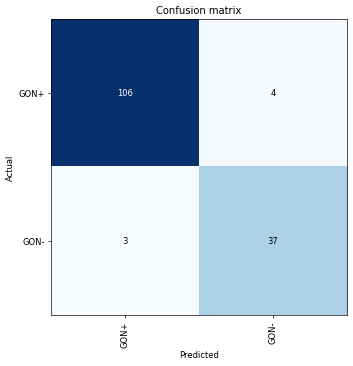

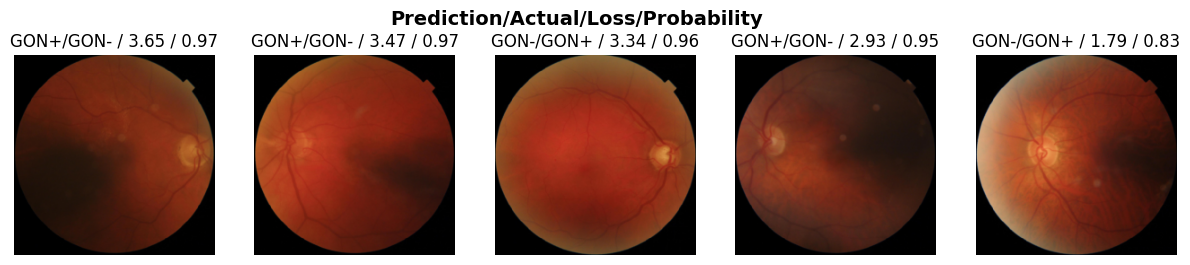

In [ ]:
# 1. Create a Classification Interpretation object
# This analyzes our model's predictions on the validation set
interp = ClassificationInterpretation.from_learner(learn)

# 2. Plot the Confusion Matrix
# This shows: True Positives, True Negatives, False Positives, and False Negatives.
# In healthcare, missing a positive case (False Negative) is very important.
interp.plot_confusion_matrix(figsize=(6,6), dpi=60)

# 3. Show a table of the top 'losses'
# This helps us see which images the model was most confident about, but got WRONG.
interp.plot_top_losses(5, nrows=1)

Visualizing model predictions (Actual vs. Predicted):


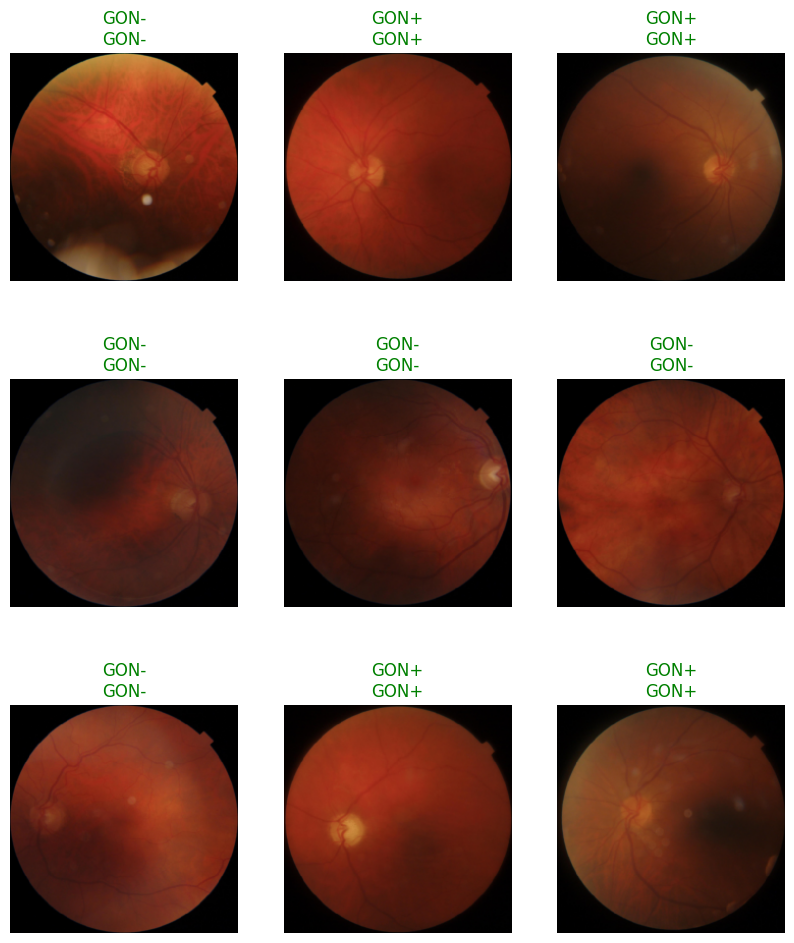

In [ ]:
# 4. Show actual vs predicted results
# Blue labels = Correct prediction
# Red labels = Incorrect prediction
print("Visualizing model predictions (Actual vs. Predicted):")
learn.show_results(max_n=9, figsize=(10,12))

Verifying Phase 1: Images with their clinical labels...


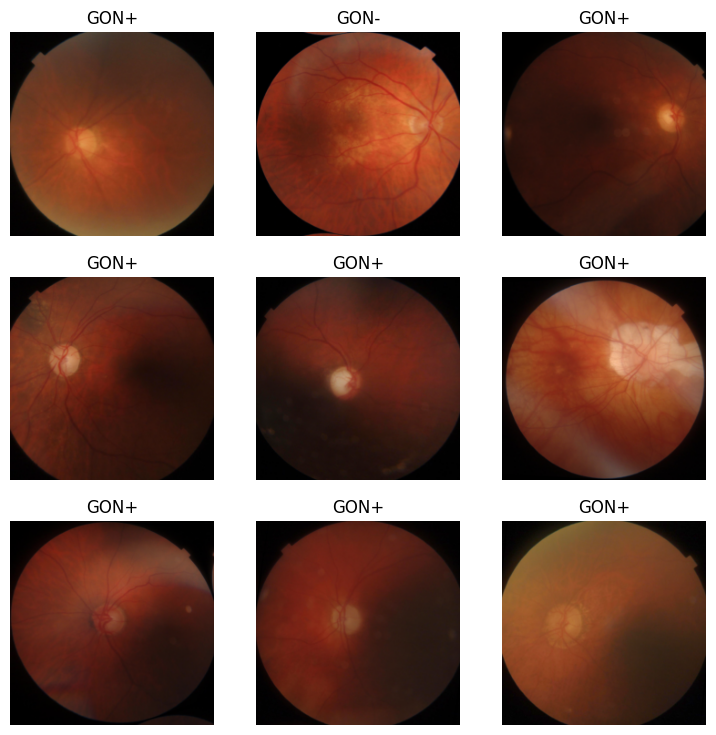

In [ ]:
from fastai.vision.all import * # Import all vision tools from fastai
import pandas as pd # Import pandas for CSV handling

# 1. Define the specific paths we verified in Phase 0
path = Path('/content/glaucoma_data/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0')
img_path = path/'Images'
csv_path = path/'Labels.csv'

# 2. Load the labels into a DataFrame
df = pd.read_csv(csv_path)

# 3. Define the DataBlock
# blocks: ImageBlock (for the photos) and CategoryBlock (for the GON labels)
# get_x: A function to find the image file using the 'Image Name' column
# get_y: Tells fastai the labels are in the 'Label' column
# item_tfms: Resizes images to 224x224 so they fit into the GPU memory
# batch_tfms: Standard data augmentation (rotation, flip, zoom) to help with small datasets
glaucoma_db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=lambda r: img_path/r['Image Name'],
    get_y=ColReader('Label'),
    splitter=TrainTestSplitter(test_size=0.2, stratify=df['Label']),
    item_tfms=Resize(460), # Resize larger first for 'Presized' augmentation
    batch_tfms=aug_transforms(size=224, min_scale=0.75) # Final size 224 with augmentation
)

# 4. Create the DataLoaders
# bs=32 means we process 32 images at a time (safe for T4 GPU)
dls = glaucoma_db.dataloaders(df, bs=32)

# 5. Show a batch to verify labeling and augmentation
print("Verifying Phase 1: Images with their clinical labels...")
dls.show_batch(max_n=9, nrows=3)

In [ ]:
import zipfile # Library to handle ZIP files
import os # Library to interact with the operating system
from pathlib import Path # Modern way to handle file paths

# Define the filename you uploaded
zip_path = '/content/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0.zip'
# Define where we want to extract the files
extract_to = '/content/glaucoma_data'

# 1. Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to) # Extract everything into the new folder
    print(f"Successfully extracted to: {extract_to}")

# 2. Set the base path to the extracted content
# Note: Sometimes ZIPs have a nested folder inside with the same name
base_path = Path(extract_to)

# 3. List the contents to verify the folder names for the next step
print("\n--- Verifying Extraction ---")
for path in base_path.rglob('*'): # Recursively look for all files/folders
    if path.is_dir():
        print(f"Folder found: {path}")
    elif path.name == 'Labels.csv':
        print(f"SUCCESS: Found Labels.csv at: {path}")

Successfully extracted to: /content/glaucoma_data

--- Verifying Extraction ---
Folder found: /content/glaucoma_data/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0
SUCCESS: Found Labels.csv at: /content/glaucoma_data/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Labels.csv
Folder found: /content/glaucoma_data/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images
